<a href="https://colab.research.google.com/github/BillJr99/Ursinus-CS357/blob/gh-pages/files/notebooks/Simple_MNIST_NN_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Robust MNIST downloader with mirror fallbacks → Kaggle-style train.csv
# Mirrors tried (in order): CVDF (GCS) → LeCun → GitHub fgnt
# Produces: /kaggle/input/digit-recognizer/train.csv
#
# After this, your original loader works:
#   data = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

import os, gzip, urllib.request, urllib.error, struct, traceback
from urllib.parse import urljoin
import numpy as np
import pandas as pd

MIRRORS = [
    "https://storage.googleapis.com/cvdf-datasets/mnist/",  # CVDF mirror
    "https://yann.lecun.com/exdb/mnist/",                   # LeCun site
    "https://raw.githubusercontent.com/fgnt/mnist/master/", # GitHub mirror
]

FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images":  "t10k-images-idx3-ubyte.gz",
    "test_labels":  "t10k-labels-idx1-ubyte.gz",
}

RAW_DIR = "./mnist_data"
os.makedirs(RAW_DIR, exist_ok=True)

KAGGLE_INPUT_DIR = "./kaggle/input/digit-recognizer"
os.makedirs(KAGGLE_INPUT_DIR, exist_ok=True)
TRAIN_CSV_PATH = os.path.join(KAGGLE_INPUT_DIR, "train.csv")
# If you want a Kaggle-style test.csv (pixels only), set this:
TEST_CSV_PATH  = os.path.join(KAGGLE_INPUT_DIR, "test.csv")  # optional

def _download_with_fallbacks(filename: str, mirrors=MIRRORS, out_dir: str = RAW_DIR, timeout: int = 30) -> str:
    """Try to download filename from a list of mirrors. Returns local path or raises."""
    last_err = None
    dest = os.path.join(out_dir, filename)
    if os.path.exists(dest):
        print(f"[MNIST-DL] Using cached: {dest}")
        return dest
    for base in mirrors:
        url = urljoin(base, filename)
        try:
            print(f"[MNIST-DL] Fetching {url} ...")
            urllib.request.urlretrieve(url, dest)  # simple & robust
            print(f"[MNIST-DL] Saved to {dest}")
            return dest
        except Exception as e:
            last_err = e
            print(f"[MNIST-DL] Mirror failed {url} :: {e}")
            traceback.print_exc()
    raise RuntimeError(f"[MNIST-DL] All mirrors failed for {filename}: {last_err}")

def _read_idx_images_gz(path_gz: str) -> np.ndarray:
    """Read IDX images (gz) -> uint8 array (N, 28, 28)."""
    with gzip.open(path_gz, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"[MNIST-PARSE] Unexpected magic for images: {magic}")
        buf = f.read()
        arr = np.frombuffer(buf, dtype=np.uint8).reshape(num, rows, cols)
        return arr

def _read_idx_labels_gz(path_gz: str) -> np.ndarray:
    """Read IDX labels (gz) -> uint8 array (N,)."""
    with gzip.open(path_gz, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"[MNIST-PARSE] Unexpected magic for labels: {magic}")
        buf = f.read()
        labels = np.frombuffer(buf, dtype=np.uint8)
        return labels

def _write_kaggle_train_csv(train_images: np.ndarray, train_labels: np.ndarray, out_csv: str) -> None:
    """Write Kaggle 'digit-recognizer' style CSV: label,pixel0,...,pixel783."""
    try:
        assert train_images.shape[0] == train_labels.shape[0]
        N = train_images.shape[0]
        X = train_images.reshape(N, -1).astype(np.uint8)
        y = train_labels.astype(np.uint8)
        pixel_cols = [f"pixel{i}" for i in range(X.shape[1])]
        df = pd.DataFrame(X, columns=pixel_cols)
        df.insert(0, "label", y)
        df.to_csv(out_csv, index=False)
        print(f"[MNIST-WRITE] Wrote {out_csv} (rows={N})")
    except Exception as e:
        print(f"[MNIST-WRITE] Error writing train CSV: {e}")
        traceback.print_exc()
        raise

def _write_kaggle_test_csv(test_images: np.ndarray, out_csv: str) -> None:
    """Optional: Write Kaggle-style test.csv with pixels only (no labels)."""
    try:
        X = test_images.reshape(test_images.shape[0], -1).astype(np.uint8)
        df = pd.DataFrame(X, columns=[f"pixel{i}" for i in range(X.shape[1])])
        df.to_csv(out_csv, index=False)
        print(f"[MNIST-WRITE] Wrote {out_csv} (rows={X.shape[0]})")
    except Exception as e:
        print(f"[MNIST-WRITE] Error writing test CSV: {e}")
        traceback.print_exc()
        raise

try:
    paths = {k: _download_with_fallbacks(v) for k, v in FILES.items()}
    train_images = _read_idx_images_gz(paths["train_images"])
    train_labels = _read_idx_labels_gz(paths["train_labels"])
    _write_kaggle_train_csv(train_images, train_labels, TRAIN_CSV_PATH)

    # Optional: also emit test.csv (unlabeled), useful for parity with Kaggle's digit-recognizer
    test_images = _read_idx_images_gz(paths["test_images"])
    _write_kaggle_test_csv(test_images, TEST_CSV_PATH)

except Exception as e:
    print(f"[MNIST-SETUP] Error: {e}")
    traceback.print_exc()


[MNIST-DL] Fetching https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz ...
[MNIST-DL] Saved to ./mnist_data/train-images-idx3-ubyte.gz
[MNIST-DL] Fetching https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz ...
[MNIST-DL] Saved to ./mnist_data/train-labels-idx1-ubyte.gz
[MNIST-DL] Fetching https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz ...
[MNIST-DL] Saved to ./mnist_data/t10k-images-idx3-ubyte.gz
[MNIST-DL] Fetching https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz ...
[MNIST-DL] Saved to ./mnist_data/t10k-labels-idx1-ubyte.gz
[MNIST-WRITE] Wrote /kaggle/input/digit-recognizer/train.csv (rows=60000)
[MNIST-WRITE] Wrote /kaggle/input/digit-recognizer/test.csv (rows=10000)


# Simple MNIST NN from scratch

In this notebook, I implemented a simple two-layer neural network and trained it on the MNIST digit recognizer dataset. It's meant to be an instructional example, through which you can understand the underlying math of neural networks better.

Here's a video I made explaining all the math and showing my progress as I coded the network: https://youtu.be/w8yWXqWQYmU

In [ ]:
# Samson Zhang: https://www.youtube.com/@SamsonZhangTheSalmon

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

data = pd.read_csv('./kaggle/input/digit-recognizer/train.csv')

In [ ]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) # shuffle before splitting into dev and training sets

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [ ]:
Y_train

array([7, 4, 6, ..., 4, 4, 0])

Our NN will have a simple two-layer architecture. Input layer $a^{[0]}$ will have 784 units corresponding to the 784 pixels in each 28x28 input image. A hidden layer $a^{[1]}$ will have 10 units with ReLU activation, and finally our output layer $a^{[2]}$ will have 10 units corresponding to the ten digit classes with softmax activation.

**Forward propagation**

$$Z^{[1]} = W^{[1]} X + b^{[1]}$$
$$A^{[1]} = g_{\text{ReLU}}(Z^{[1]}))$$
$$Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}$$
$$A^{[2]} = g_{\text{softmax}}(Z^{[2]})$$

**Backward propagation**

$$dZ^{[2]} = A^{[2]} - Y$$
$$dW^{[2]} = \frac{1}{m} dZ^{[2]} A^{[1]T}$$
$$dB^{[2]} = \frac{1}{m} \Sigma {dZ^{[2]}}$$
$$dZ^{[1]} = W^{[2]T} dZ^{[2]} .* g^{[1]\prime} (z^{[1]})$$
$$dW^{[1]} = \frac{1}{m} dZ^{[1]} A^{[0]T}$$
$$dB^{[1]} = \frac{1}{m} \Sigma {dZ^{[1]}}$$

**Parameter updates**

$$W^{[2]} := W^{[2]} - \alpha dW^{[2]}$$
$$b^{[2]} := b^{[2]} - \alpha db^{[2]}$$
$$W^{[1]} := W^{[1]} - \alpha dW^{[1]}$$
$$b^{[1]} := b^{[1]} - \alpha db^{[1]}$$

**Vars and shapes**

Forward prop

- $A^{[0]} = X$: 784 x m
- $Z^{[1]} \sim A^{[1]}$: 10 x m
- $W^{[1]}$: 10 x 784 (as $W^{[1]} A^{[0]} \sim Z^{[1]}$)
- $B^{[1]}$: 10 x 1
- $Z^{[2]} \sim A^{[2]}$: 10 x m
- $W^{[1]}$: 10 x 10 (as $W^{[2]} A^{[1]} \sim Z^{[2]}$)
- $B^{[2]}$: 10 x 1

Backprop

- $dZ^{[2]}$: 10 x m ($~A^{[2]}$)
- $dW^{[2]}$: 10 x 10
- $dB^{[2]}$: 10 x 1
- $dZ^{[1]}$: 10 x m ($~A^{[1]}$)
- $dW^{[1]}$: 10 x 10
- $dB^{[1]}$: 10 x 1

In [ ]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [ ]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [ ]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[8 3 8 ... 8 8 3] [7 4 6 ... 4 4 0]
0.09566101694915254
Iteration:  10
[8 3 0 ... 8 7 3] [7 4 6 ... 4 4 0]
0.1167457627118644
Iteration:  20
[7 3 3 ... 7 0 0] [7 4 6 ... 4 4 0]
0.16389830508474576
Iteration:  30
[7 3 3 ... 7 0 0] [7 4 6 ... 4 4 0]
0.214864406779661
Iteration:  40
[7 3 3 ... 7 0 0] [7 4 6 ... 4 4 0]
0.2552033898305085
Iteration:  50
[7 3 9 ... 7 0 0] [7 4 6 ... 4 4 0]
0.2955593220338983
Iteration:  60
[7 3 9 ... 7 7 0] [7 4 6 ... 4 4 0]
0.3283728813559322
Iteration:  70
[7 9 9 ... 7 7 0] [7 4 6 ... 4 4 0]
0.3684915254237288
Iteration:  80
[7 9 4 ... 7 7 0] [7 4 6 ... 4 4 0]
0.40835593220338984
Iteration:  90
[7 9 4 ... 7 7 0] [7 4 6 ... 4 4 0]
0.4470677966101695
Iteration:  100
[7 9 6 ... 9 7 0] [7 4 6 ... 4 4 0]
0.4860847457627119
Iteration:  110
[7 9 6 ... 9 7 0] [7 4 6 ... 4 4 0]
0.5209322033898305
Iteration:  120
[7 9 6 ... 9 7 0] [7 4 6 ... 4 4 0]
0.5533050847457627
Iteration:  130
[7 9 6 ... 9 7 0] [7 4 6 ... 4 4 0]
0.5832372881355932
Iteration:  140

~85% accuracy on training set.

In [ ]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Let's look at a couple of examples:

Prediction:  [7]
Label:  7


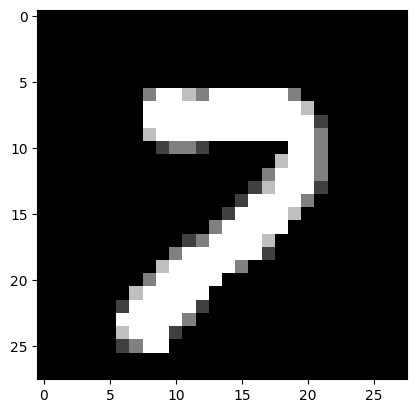

Prediction:  [4]
Label:  4


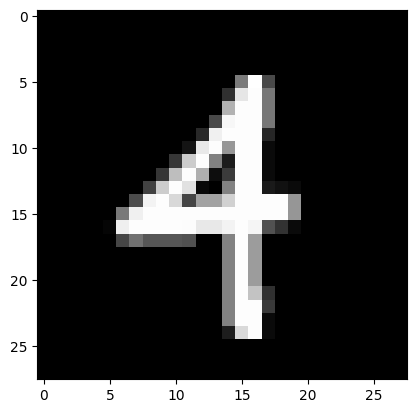

Prediction:  [6]
Label:  6


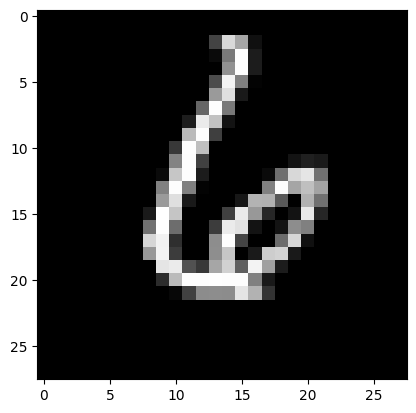

Prediction:  [6]
Label:  6


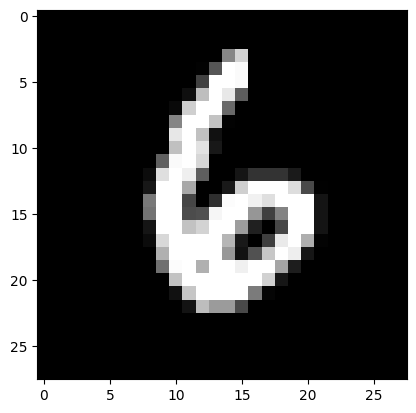

In [ ]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

Finally, let's find the accuracy on the dev set:

In [ ]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[9 8 3 6 7 8 1 5 8 9 0 3 8 1 9 7 4 5 4 3 6 3 0 6 7 1 4 1 9 5 3 4 7 7 9 2 0
 0 5 9 0 7 4 2 2 2 8 9 3 1 7 3 2 9 6 2 1 0 4 4 2 8 8 0 4 6 9 3 0 0 1 1 1 2
 6 6 8 0 7 8 3 2 2 1 3 9 7 4 5 4 3 6 9 8 1 4 0 3 7 4 2 9 6 9 4 9 1 4 7 8 6
 9 0 5 6 8 8 2 0 9 6 6 2 8 5 9 0 3 8 0 5 3 8 2 8 0 0 9 9 6 8 3 6 4 1 4 7 4
 6 4 5 6 4 3 7 0 6 4 5 9 4 1 5 6 5 2 4 3 2 2 6 5 8 4 0 8 2 9 6 5 2 4 6 9 6
 8 2 7 9 0 0 6 3 8 8 7 5 7 5 0 9 1 5 9 6 2 3 9 8 4 1 4 3 7 4 8 6 3 2 4 0 4
 3 6 6 9 2 6 9 6 5 3 7 6 9 1 4 1 4 9 7 4 5 8 2 7 8 8 0 6 5 6 1 7 3 0 6 2 0
 0 2 0 6 6 2 2 9 9 7 0 7 9 1 0 4 1 4 1 1 6 7 9 9 4 8 9 7 6 5 4 4 6 3 5 1 9
 4 6 4 7 6 7 0 6 0 1 6 4 4 5 4 5 2 0 6 0 4 5 9 3 0 3 5 5 4 5 8 7 1 8 5 3 1
 3 9 8 1 8 1 6 7 8 4 1 8 7 8 6 4 7 4 1 2 1 1 0 7 8 4 2 1 4 3 3 9 0 7 1 8 2
 9 2 7 6 0 0 8 4 2 6 7 3 1 0 0 6 6 9 3 7 1 1 5 0 4 1 6 0 5 9 7 0 1 6 6 8 7
 7 6 4 2 1 4 1 6 9 5 7 2 4 8 4 7 7 8 6 1 9 8 2 6 7 8 7 8 6 5 3 9 6 7 1 5 2
 2 9 4 8 6 9 8 0 6 6 8 4 2 8 7 4 4 3 2 1 4 9 1 1 5 3 0 4 5 2 2 6 2 0 1 0 3
 3 7 3 9 2 4 9 8 5 5 8 8 

np.float64(0.852)

Still 84% accuracy, so our model generalized from the training data pretty well.